In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

In [4]:
# set global seaborn style
sns.set_theme(
    context="notebook",
    style="ticks",
    palette="muted",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Exploratory Data Analysis (EDA)

In [5]:
df = pd.read_csv("../data/raw/stroke.csv")

In [6]:
df.shape

(5110, 12)

Há 5110 linhas e 12 colunas no conjunto de dados.

In [7]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


O conjunto de dados possui as seguintes colunas:

*    `id`:
*    `gender`:
*    `age`:
*    `hypertension`:
*    `heart_disease`:
*    `ever_married`:
*    `work_type`:
*    `residence_type`:
*    `avg_glucose_level`:
*    `bmi`:
*    `smoking_status`:
*    `stroke`:

In [8]:
# drop ID column to prevent accidental usage
if "id" in df.columns:
    df = df.drop(columns=["id"])

Há algumas inconcistências no conjunto de dados. Algumas *strings* estão capitalizadas e outras não.

Vamos tornar isso uniforme colocando tudo em minúsculas e substituindo espaços por *underscores*. Dessa forma, removemos todas as inconsistências nos dados.

In [9]:
from preprocessing import normalize_strings

df = normalize_strings(df)

In [10]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,female,61.0,0,0,yes,self-employed,rural,202.21,NaN,never_smoked,1
2,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,female,79.0,1,0,yes,self-employed,rural,174.12,24.0,never_smoked,1


## Variável Alvo (`stroke`)

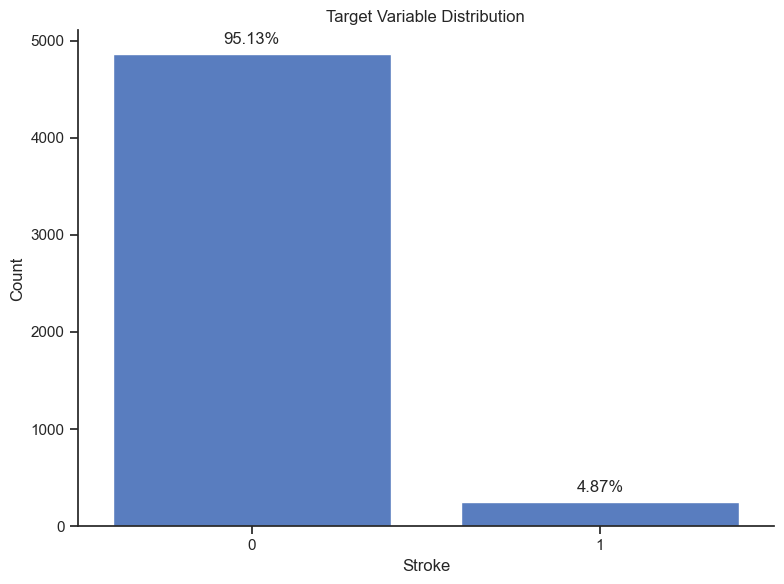

In [11]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="stroke",
)

total = len(df)

for p in ax.patches:
    height = int(p.get_height())
    percentage = 100 * height / total
    ax.annotate(
        f"{percentage:.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

ax.set_title("Target Variable Distribution")
ax.set_xlabel("Stroke")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [12]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

A variável alvo apresenta forte desbalanceamento no conjunto de dados. Observa-se uma predominância expressiva da classe 0 (pacientes sem AVC) em relação à classe 1 (pacientes com AVC). Do total de 5110 pacientes, 4861 correspondem a pacientes sem ocorrência de AVC, enquanto apenas 249 representam casos positivos. Assim, os pacientes com AVC representam apenas 4.87% das amostras.

## Variáveis Categóricas

In [13]:
categorical_vars = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "residence_type",
    "smoking_status",
]

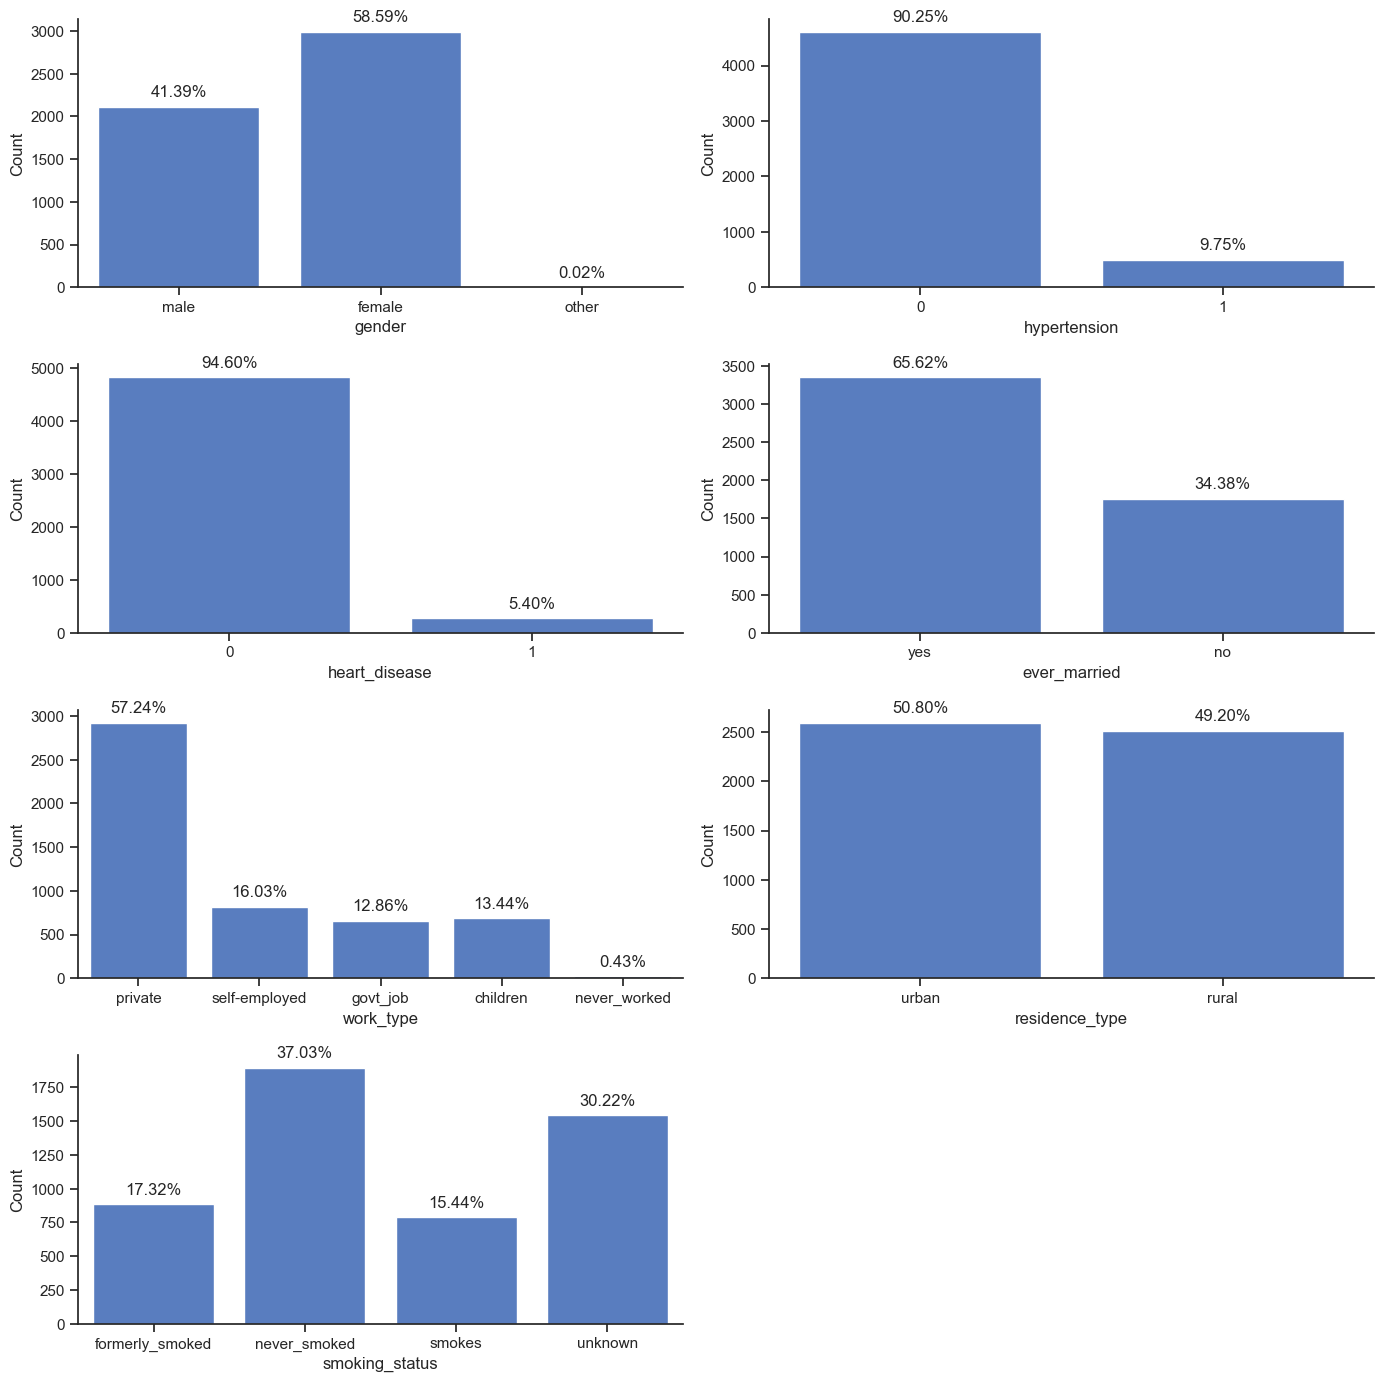

In [14]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(14, 14))
axs = axs.flatten()

for i, var in enumerate(categorical_vars):
    ax = axs[i]

    sns.countplot(
        data=df,
        x=var,
        ax=ax,
    )

    total = len(df)

    for p in ax.patches:
        height = int(p.get_height())
        percentage = 100 * height / total
        ax.annotate(
            f"{percentage:.2f}%",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

    ax.set_xlabel(var)
    ax.set_ylabel("Count")

# remove empty subplots if any
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Observações:

*    `gender`: Há uma predominância do gênero feminino (58.59%), seguido do masculino (41.29%). A categoria "outro" é residual (0.02%), o que justifica sua remoção por irrelevância estatística.
*    `hypertension`: 9.75% dos pacientes são hipertensos. A hipertensão é um fator de risco para AVC; portanto, mesmo sendo minoritária, tende a ser altamente informativa.
*    `heart_disease`: Apenas 5.40% dos pacientes possuem histórico de doença cardíaca; ainda assim, essa condição é clinicamente relevante.
*    `ever_married`: 65.62% dos pacientes já se casaram pelo menos uma vez.
*    `work_type`: Pacientes que trabalham no setor privado representam 57.24% do conjunto de dados.
*    `residence_type`: A distribuição de pacientes entre áreas urbanas e rurais é equilibrada (50.80% vs 49.20%).
*    `smoking_status`: 37.03% dos pacientes nunca fumou. A categoria “unknown” possui um número significativo de pacientes.

## Variáveis Contínuas

In [15]:
continuous_vars = [
    "age",
    "avg_glucose_level",
    "bmi",
]

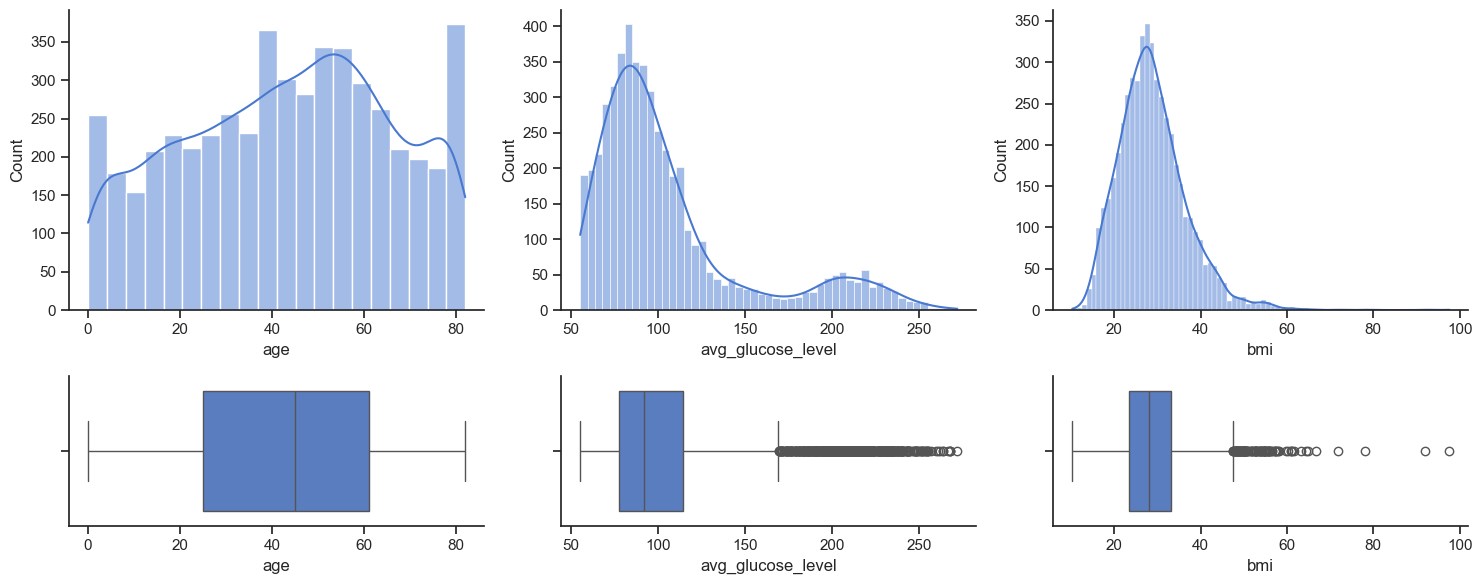

In [16]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    gridspec_kw={"height_ratios": [2, 1]},
    figsize=(15, 6),
)

for i, var in enumerate(continuous_vars):
    sns.histplot(
        data=df,
        x=var,
        kde=True,
        ax=axs[0, i],
    )

    sns.boxplot(
        data=df,
        x=var,
        ax=axs[1, i],
    )

plt.tight_layout()
plt.show()

Observações:

*    `age`: A idade dos pacientes varia de jovens a idosos, com maior concentração entre 40 e 60 anos. Não há outliers.
*    `avg_glucose_level`: A distribuição é assimétrica à direita, com cauda longa e valores elevados (até ~270). A maioria dos pacientes apresenta nível médio de glicose entre 50 e 125. Há outliers.
*    `bmi`: A distribuição é assimétrica à direita, embora menos acentuada que `avg_glucose_level`. A maioria dos pacientes apresenta IMC entre 20 e 40. Há outliers.

## Análise Bivariada

Essa etapa estuda a relação entre duas variáveis ao mesmo tempo.

Enquanto a análise univariada responde "como é essa variável sozinha?", a análise bivariada responde "como uma variável se comporta em relação à outra?".

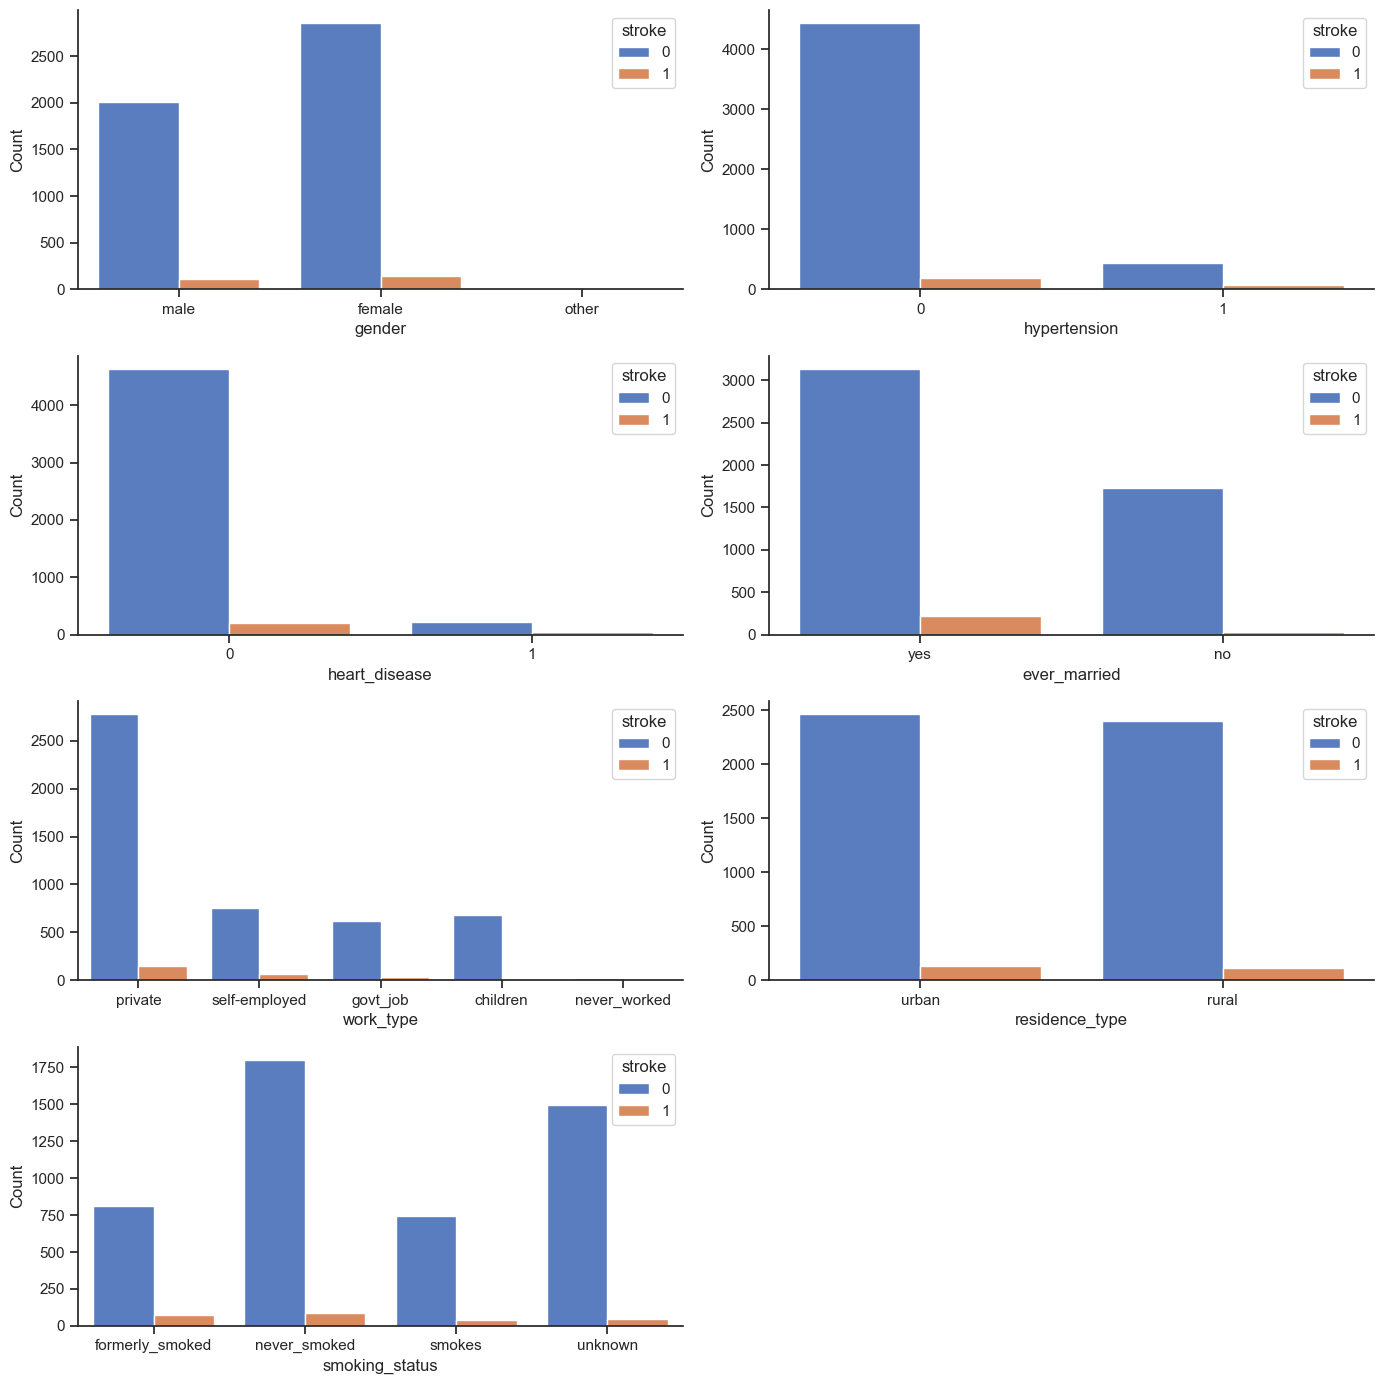

In [17]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(14, 14))
axs = axs.flatten()

for i, var in enumerate(categorical_vars):
    ax = axs[i]

    sns.countplot(
        data=df,
        x=var,
        hue="stroke",
        ax=ax,
    )

    ax.set_xlabel(var)
    ax.set_ylabel("Count")

# remove empty subplots if any
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [18]:
for var in categorical_vars:
    # count occurrences of stroke per category
    counts = (
        df
        .groupby([var, "stroke"])
        .size()
        .unstack(fill_value=0)
    )

    # total samples per category
    totals = counts.sum(axis=1)

    # stroke rate (%)
    stroke_rate = (counts[1] / totals * 100).round(2)

    summary = (
        pd.DataFrame({
            "stroke_rate (%)": stroke_rate,
            "count": totals,
        })
        .sort_values(by="stroke_rate (%)", ascending=False)
    )
    display(summary)


,stroke_rate (%),count
gender,,
male,5.11,2115
female,4.71,2994
other,0.00,1


,stroke_rate (%),count
hypertension,,
1,13.25,498
0,3.97,4612


,stroke_rate (%),count
heart_disease,,
1,17.03,276
0,4.18,4834


,stroke_rate (%),count
ever_married,,
yes,6.56,3353
no,1.65,1757


,stroke_rate (%),count
work_type,,
self-employed,7.94,819
private,5.09,2925
govt_job,5.02,657
children,0.29,687
never_worked,0.00,22


,stroke_rate (%),count
residence_type,,
urban,5.20,2596
rural,4.53,2514


,stroke_rate (%),count
smoking_status,,
formerly_smoked,7.91,885
smokes,5.32,789
never_smoked,4.76,1892
unknown,3.04,1544


A análise das taxas de AVC por categoria evidencia associações fortes com comorbidades clínicas, especialmente hipertensão e doença cardíaca, cujas taxas de ocorrência de AVC são aproximadamente três e quatro vezes maiores, respectivamente, em comparação aos pacientes sem essas condições.
Observa-se ainda maior taxa de AVC entre ex-fumantes em relação a fumantes atuais, padrão consistente com achados da literatura e possivelmente associado a viés de sobrevivência.

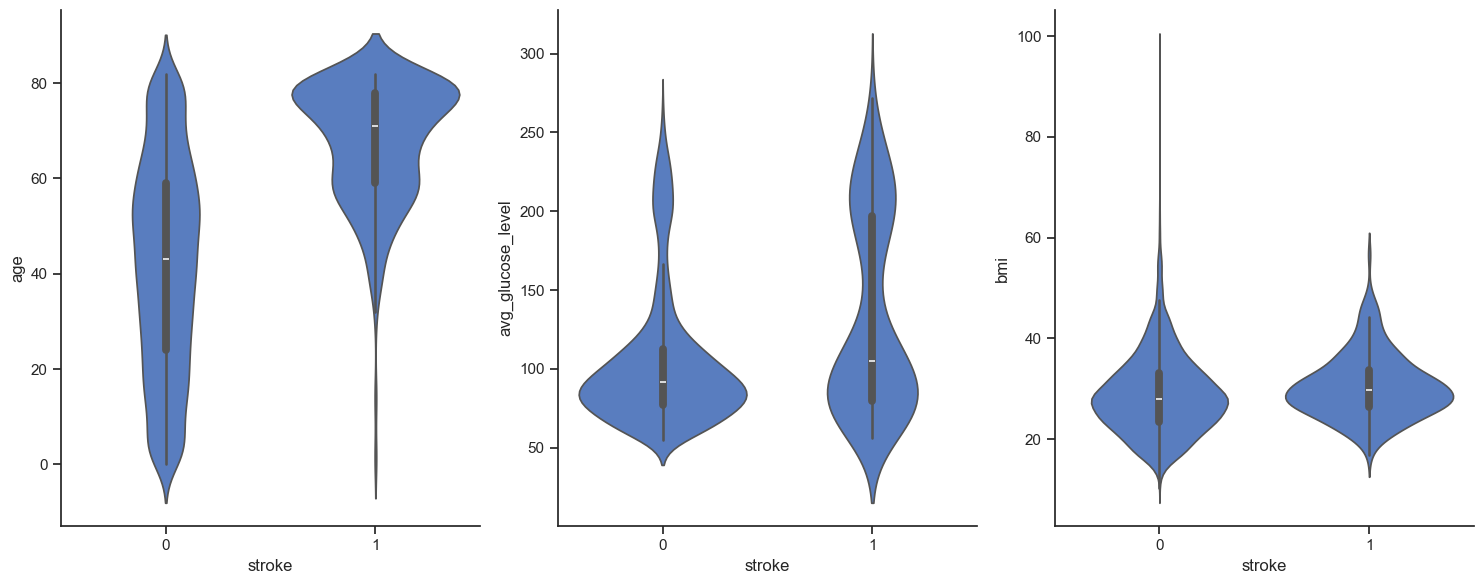

In [19]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 6),
)

for i, var in enumerate(continuous_vars):
    ax = axs[i]

    sns.violinplot(
        data=df,
        x="stroke",
        y=var,
        ax=ax,
    )

plt.tight_layout()
plt.show()

A variável idade apresenta clara separação, com pacientes acometidos por AVC concentrando-se em faixas etárias mais elevadas. O nível médio de glicose também demonstra deslocamento significativo da distribuição no grupo com AVC, além de maior dispersão e cauda superior mais longa, refletindo heterogeneidade clínica relevante. Em contraste, o IMC apresenta diferenças mais discretas, com ampla sobreposição entre os grupos.

## Análise Multivariada

Essa etapa estuda a relação entre múltiplas variáveis ao mesmo tempo.

Não podemos pegar uma variável categórica e colocá-la em um modelo de ML. Os modelos só conseguem lidar com números. Portanto, precisamos converter os dados categóricos.

Uma dessas técnicas de codificação é o *one-hot encoding*. Se a variável `gender` tem os valores possíveis `male`, `female` e `other`, podemos representar um paciente feminino como (0, 1, 0). Nesse caso, o valor `female` está ativo, ou "hot", então recebe 1, enquanto os valores restantes não estão ativos, ou "cold", e por isso recebem 0.

In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
categorical_vars = [
    "gender",
    "ever_married",
    "work_type",
    "residence_type",
    "smoking_status",
]

custom_drop = [
    "female",
    "no",
    "govt_job",
    "rural",
    "unknown",
]

column_transformer = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(drop=custom_drop, sparse_output=False),
            categorical_vars,
        )
    ],
    remainder="passthrough",  # keep other columns unchanged
    verbose_feature_names_out=False,
).set_output(transform="pandas")

encoded_df = column_transformer.fit_transform(df)

In [22]:
encoded_df.head()

,gender_male,gender_other,ever_married_yes,work_type_children,work_type_never_worked,work_type_private,work_type_self-employed,residence_type_urban,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,67.0,0,1,228.69,36.6,1
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,61.0,0,0,202.21,NaN,1
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,80.0,0,1,105.92,32.5,1
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,49.0,0,0,171.23,34.4,1
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,79.0,1,0,174.12,24.0,1


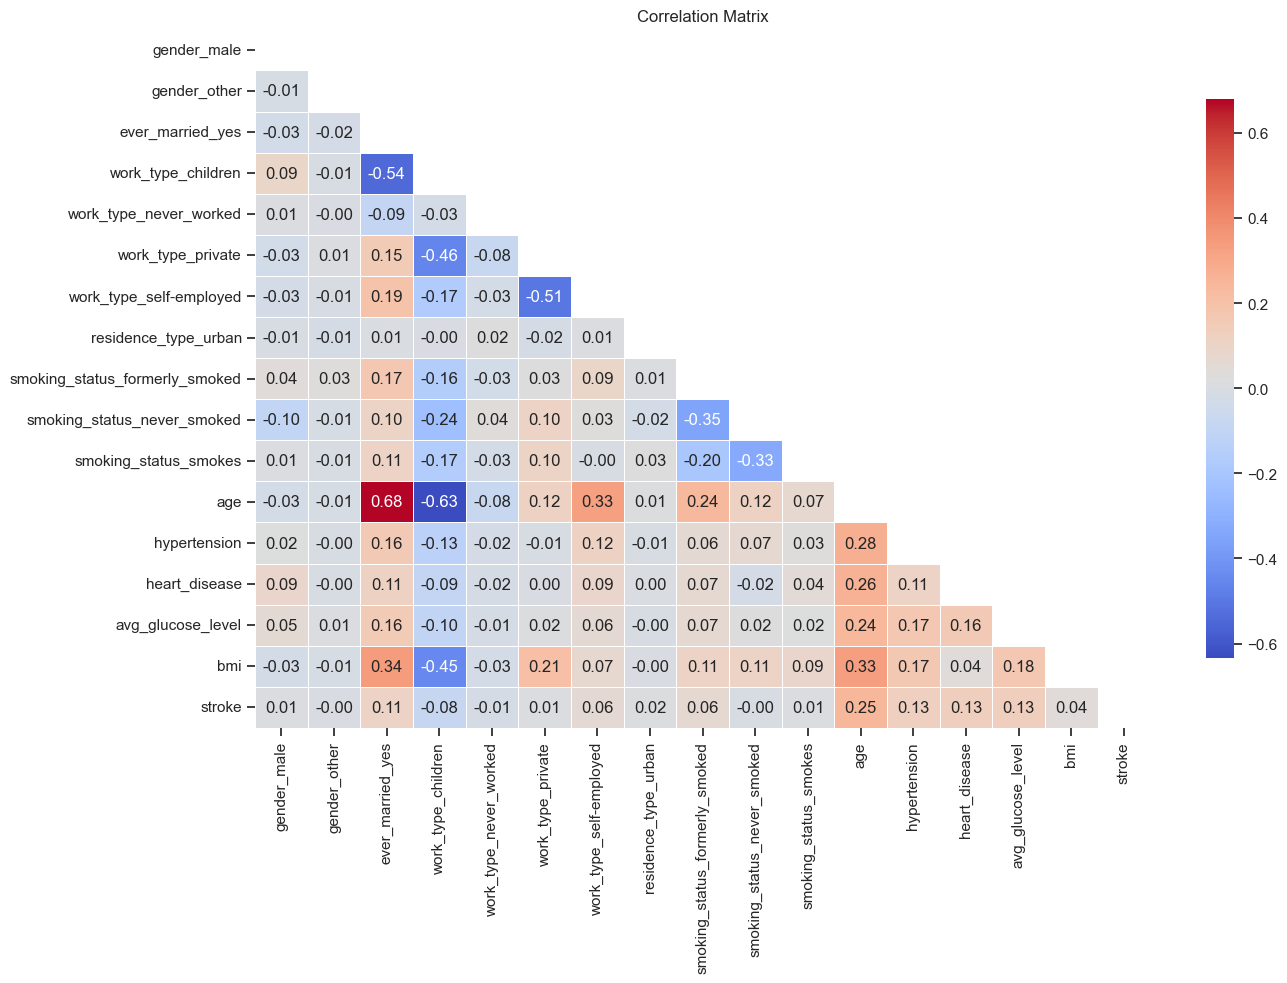

In [23]:
corr_matrix = encoded_df.corr()

# mask to hide upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    mask=mask,
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

A matriz de correlação (mapa de calor) fornece uma visualização da correlação entre todos os pares de variáveis no conjunto de dados. A cor de cada célula representa o coeficiente de correlação entre o par de variáveis: azul para correlação negativa e vermelho para correlação positiva. Quanto mais escura a cor, mais forte é a correlação.

Correlação:

*    `r = 1`: Correlação positiva perfeita (uma variável aumenta, a outra também, na mesma proporção).
*    `r = -1`: Correlação negativa perfeita (uma variável aumenta, a outra diminui).
*    `r = 0`: Ausência de relação linear.

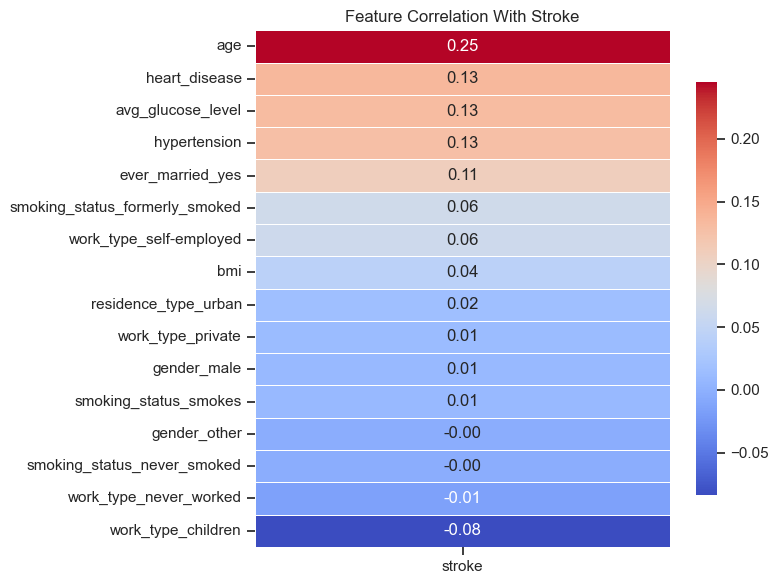

In [24]:
target_corr = corr_matrix["stroke"].drop("stroke").sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(
    target_corr.to_frame(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation With Stroke")

plt.tight_layout()
plt.show()

As correlações observadas são, em sua maioria, fracas a moderadas, comportamento esperado em dados clínicos reais. A variável `age` destaca-se como o fator isolado mais correlacionado com AVC, enquanto comorbidades clínicas apresentam correlação positiva consistente, porém de baixa magnitude, indicando contribuição relevante ao risco de AVC, mas insuficiente de forma isolada.

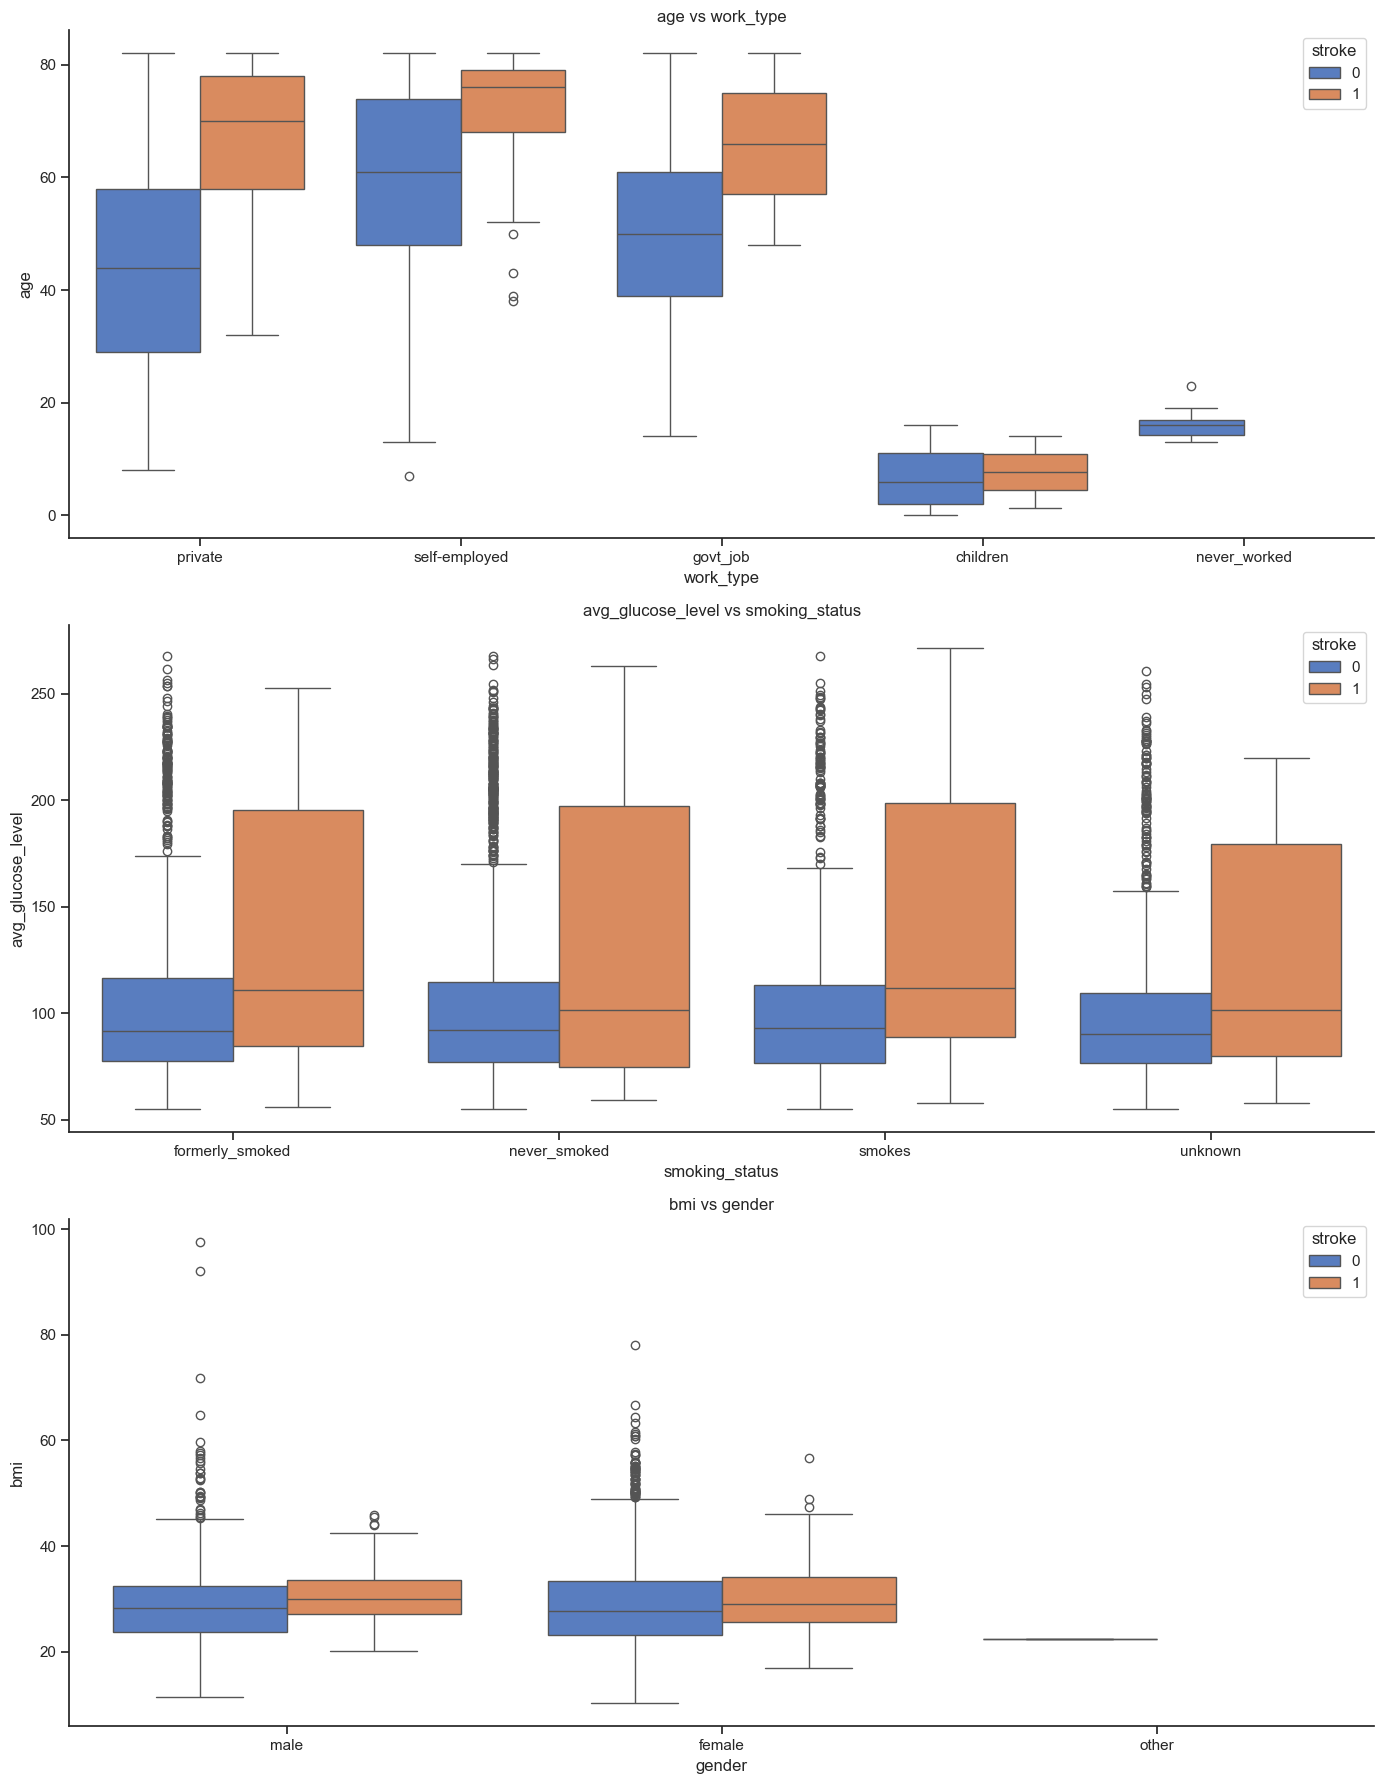

In [25]:
features_to_plot = [
    ("work_type", "age"),
    ("smoking_status", "avg_glucose_level"),
    ("gender", "bmi"),
]

fix, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 18),
    sharex=False
)

for i, (x_col, y_col) in enumerate(features_to_plot):
    ax = axs[i]

    sns.boxplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="stroke",
        ax=ax,
    )

    ax.set_title(f"{y_col} vs {x_col}")

plt.tight_layout()
plt.show()

Vamos examinar a distribuição de `age`, `avg_glucose_level` e `bmi` em pacientes com e sem AVC utilizando um `pairplot`. Essa visualização permite uma análise exploratória multivariada, possibilitando observar relações par a par e padrões condicionados ao status de AVC.

O objetivo do `pairplot` é avaliar visualmente o grau de sobreposição entre classes.

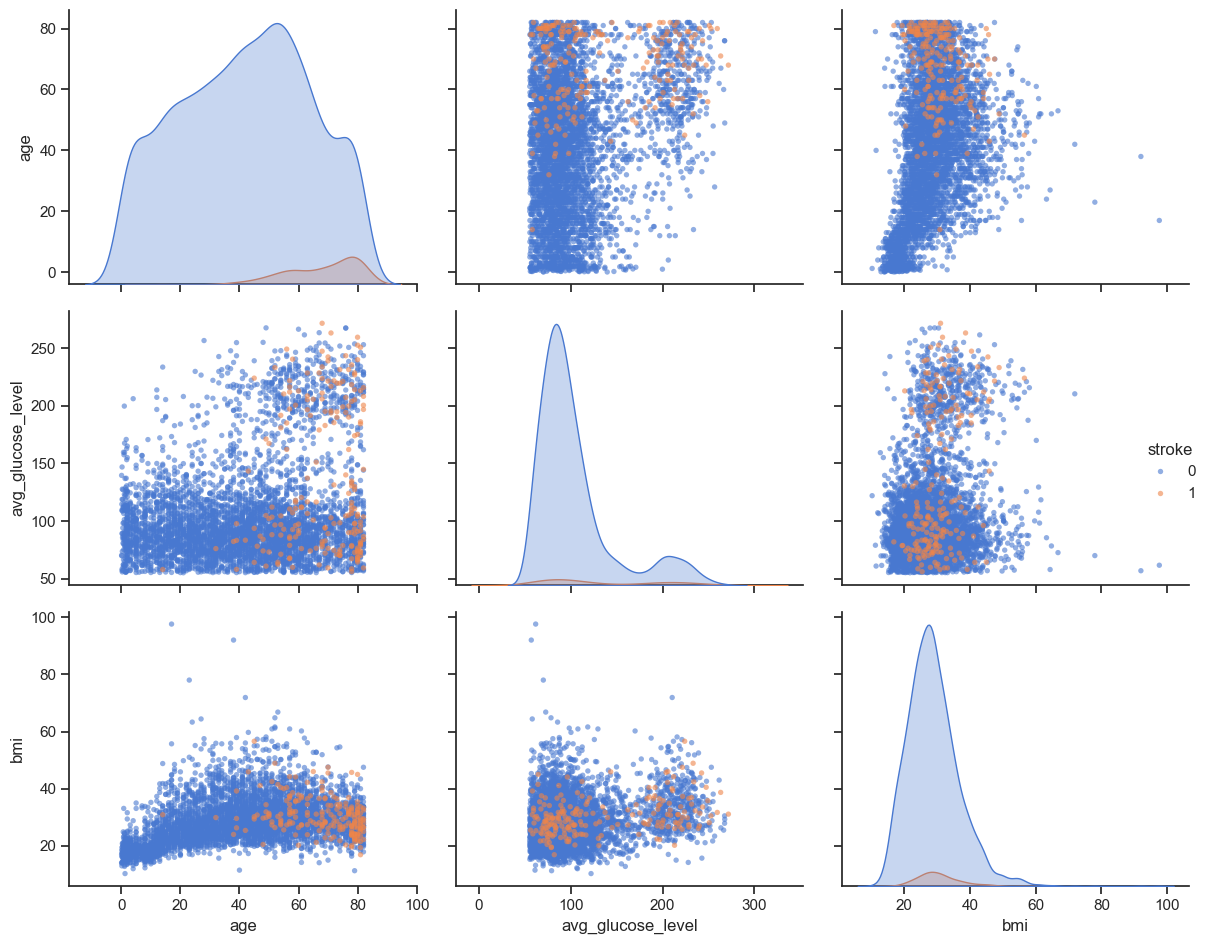

In [26]:
subset = df[[
    "age",
    "avg_glucose_level",
    "bmi",
    "stroke"
]].copy()

subset.dropna(inplace=True)

# In imbalanced datasets, the majority class (0) often covers  the minority (1).
# The solution is sort by target so "1" comes last.
# Seaborn plots in row order, so "1" will be rendered on top of "0", ensuring visibility.
subset = subset.sort_values(by="stroke", ascending=True)

sns.pairplot(
    subset,
    hue="stroke",
    diag_kind="kde",
    height=3.2,
    aspect=1.2,
    plot_kws={
        "alpha": 0.6,
        "s": 15,
        "edgecolor": "none"
    },
    diag_kws={
        "fill": True,
        "alpha": 0.3
    }
)

plt.tight_layout()
plt.show()

Os gráficos confirmam nossas conclusões anteriores: pacientes com AVC tendem a apresentar idade mais elevada e níveis médios de glicose superiores, enquanto a distribuição do IMC é semelhante à observada em pacientes sem histórico de AVC.

## Outras Análises

### Missing Values

In [27]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

A coluna `bmi` possui 201 valores ausentes. Existe diferentes estratégias para lidar com valores ausentes, incluindo remoção das observações, imputar novos valores ou deixá-los como estão.

Considerando o número relativamente grande de valores ausentes, é razoável imputar esses valores.

Iremos avaliar:
  * Imputação pela mediana, um método univariado, simples e robusto a outliers.
  * Imputação baseada em k-Nearest Neighbors (KNN), um método multivariado que estima os valores ausentes a partir de observações semelhantes no espaço das variáveis numéricas.

O objetivo é comparar o impacto dessas estratégias nas métricas finais do modelo, avaliando se abordagens mais complexas oferecem ganho real em desempenho preditivo neste problema.

A imputação de valores ausentes não é realizada nesta etapa para evitar vazamento de informação antes da separação dos dados. As estratégias de imputação serão incorporadas aos pipelines de pré-processamento e ajustadas exclusivamente no conjunto de treino durante a etapa de modelagem.

### Duplicates

In [28]:
duplicated_rows = df.duplicated().sum()
print("Duplicated Rows:", duplicated_rows)

Duplicated Rows: 0


Não há linhas duplicadas no conjunto de dados.

### Outliers

In [29]:
from preprocessing import count_outliers

continuous_vars = [
    "age",
    "avg_glucose_level",
    "bmi"
]

outliers = {column: count_outliers(df[column]) for column in continuous_vars}
print("Outliers:", outliers)

Outliers: {'age': np.int64(0), 'avg_glucose_level': np.int64(627), 'bmi': np.int64(110)}


A coluna `avg_glucose_level` tem 627 outliers e a coluna `bmi` tem 119 outliers.

Existem diferentes estratégias para lidar com outliers, como a remoção das observações, *capping/winsorization*, a transformação das variáveis ou deixar os valores como estão.

Remover os outliers poderia resultar em perda significativa de informação.

Dessa forma, para as colunas `avg_glucose_level` e `bmi`, vamos aplicar uma transformação logarítmica, com o objetivo de reduzir a assimetria das distribuições e atenuar a influência de valores extremos.

In [30]:
zero_or_negative_values = {column: (df[column] <= 0).sum() for column in continuous_vars}
print("Zero or Negative Values:", zero_or_negative_values)

Zero or Negative Values: {'age': np.int64(0), 'avg_glucose_level': np.int64(0), 'bmi': np.int64(0)}


Não existem valores zero ou negativos nessas colunas.

In [31]:
df["avg_glucose_level"] = np.log1p(df["avg_glucose_level"])
df["bmi"] = np.log1p(df["bmi"])

In [32]:
continuous_vars = [
    "age",
    "avg_glucose_level",
    "bmi"
]

outliers = {column: count_outliers(df[column]) for column in continuous_vars}
print("Outliers:", outliers)

Outliers: {'age': np.int64(0), 'avg_glucose_level': np.int64(384), 'bmi': np.int64(51)}


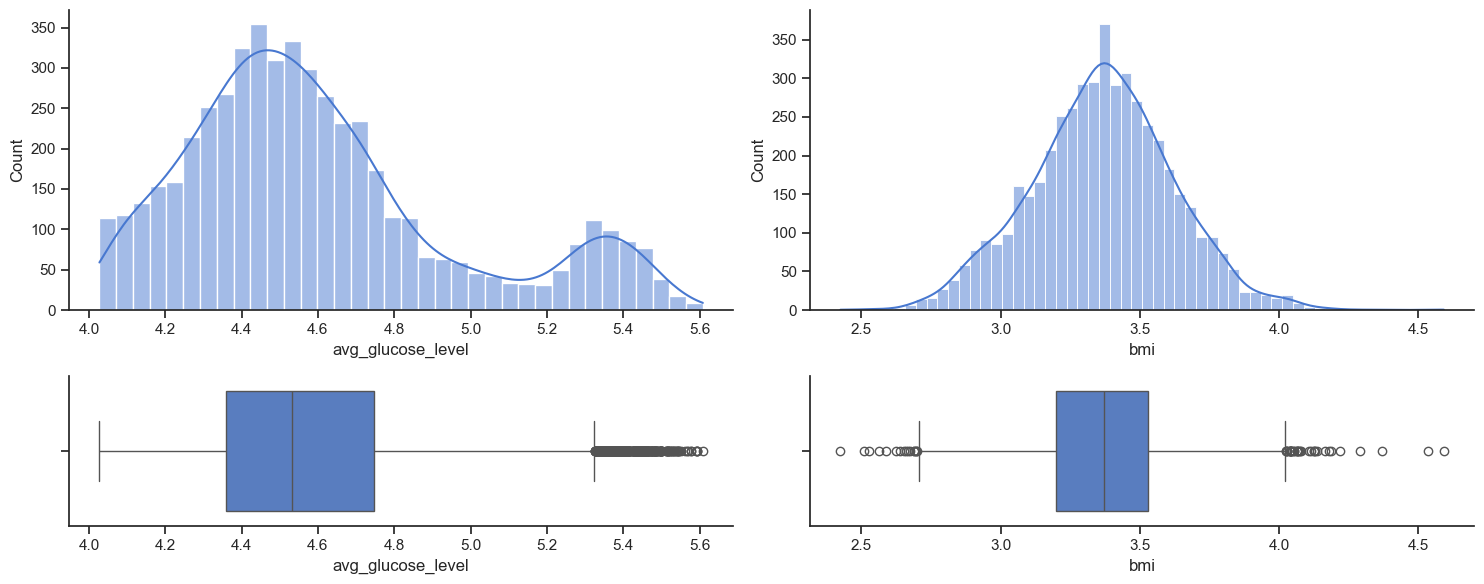

In [34]:
continuous_vars = [
    # "age",
    "avg_glucose_level",
    "bmi"
]

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    gridspec_kw={"height_ratios": [2, 1]},
    figsize=(15, 6),
)

for i, var in enumerate(continuous_vars):
    sns.histplot(
        data=df,
        x=var,
        kde=True,
        ax=axs[0, i],
    )

    sns.boxplot(
        data=df,
        x=var,
        ax=axs[1, i],
    )

plt.tight_layout()
plt.show()

A transformação logarítmica reduziu o número de outliers nas colunas `avg_glucose_level` e `bmi`.

A transformação no DataFrame não é realizada nesta etapa para evitar vazamento de informação antes da separação dos dados. Essa estratégia será incorporada aos pipelines de pré-processamento e ajustadas exclusivamente no conjunto de treino durante a etapa de modelagem.

### Encoding

In [35]:
categorical_vars = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "residence_type",
    "smoking_status",
]

# check unique values in categorical columns
unique_categorical_values = {column: df[column].unique() for column in categorical_vars}
print(unique_categorical_values)

{'gender': <StringArray>
['male', 'female', 'other']
Length: 3, dtype: str, 'hypertension': array([0, 1]), 'heart_disease': array([1, 0]), 'ever_married': <StringArray>
['yes', 'no']
Length: 2, dtype: str, 'work_type': <StringArray>
['private', 'self-employed', 'govt_job', 'children', 'never_worked']
Length: 5, dtype: str, 'residence_type': <StringArray>
['urban', 'rural']
Length: 2, dtype: str, 'smoking_status': <StringArray>
['formerly_smoked', 'never_smoked', 'smokes', 'unknown']
Length: 4, dtype: str}


O valor `other` na coluna `gender` e `unknown` na coluna `smoking_status` não são esperados.

Dependendo do número de ocorrências dessas categorias, pode fazer sentido agrupá-las em uma das categorias existentes ou criar uma categoria separada para elas.

In [36]:
other_gender_count = (df["gender"] == "other").sum()
print(other_gender_count)

1


In [37]:
unknown_smoking_count = (df["smoking_status"] == "unknown").sum()
print(unknown_smoking_count)

1544


Considerando que a categoria de gênero `other` possui apenas uma ocorrência, podemos remover essa linha, pois é improvável que ela tenha um impacto significativo na análise.

Já para a categoria unknown em `smoking_status`, como temos um número relativamente de ocorrências (1544), não é apropriado simplesmente remover essas linhas. Podemos tratar `unknown` como uma categoria separada.

## Resultados (EDA)

A variável alvo apresenta forte desbalanceamento no conjunto de dados, com apenas ~5% dos pacientes classificados como casos positivos de AVC, caracterizando um problema de **classificação rara**.

A idade é o fator isolado mais fortemente associado ao AVC:
  * Pacientes com AVC concentram-se majoritariamente em faixas etárias mais elevadas.
  * A separação entre grupos é clara, ainda que em sobreposição, indicando alto poder preditivo, mas não determinístico.

O nível médio de glicose demonstra associação relevante:
  * Pacientes com AVC apresentam valores mais elevados, maior variância e cauda superior mais longa.
  * A distribuição sugere relação não linear e heterogeneidade clínica importante.

O Índice de Massa Corporal (IMC) apresenta comportamento semelhante entre pacientes com e sem AVC:
  * As diferenças são sutis e há ampla sobreposição entre as classes.
  * O IMC, isoladamente, apresenta baixo poder discriminativo.

Comorbidades clínicas, especialmente hipertensão e doença cardíaca, estão associadas a taxas substancialmente mais altas de AVC:
  * Apesar de pouco frequentes, são variáveis clinicamente relevantes e informativas.

As variáveis sociodemográficas e comportamentais (estado civil, tipo de trabalho e tabagismo) exibem associações moderadas:
  * Ex-fumantes apresentam maior taxa de AVC do que fumantes atuais, padrão consistente com achados da literatura e possível viés de sobrevivência.

As correlações lineares com a variável alvo são fracas a moderadas, comportamento esperado em dados clínicos reais, indicando que:
  * Nenhuma variável isolada explica o desfecho.
  * O risco de AVC emerge da interação entre múltiplos fatores.

A análise multivariada confirma forte sobreposição entre classes, reforçando a complexidade do problema e a necessidade de modelos capazes de capturar interações e não linearidades.

## Próximos Passos

### Problema:

  * Classificação binárias altamente desbalanceada → **accuracy** é inadequada como métrica principal.
  * Priorizar **recall**, **PR-AUC**, **ROC-AUC**, e análise de custo de erro (Falso Negativo).

### Pré-Processamento:

  * Tratar variáveis categóricas com **one-hot encoding**, com cuidado para evitar multicolinearidade.
  * Considerar tratamento de outliers (especialmente em glicose e IMC), sem remoção agressiva - outliers podem ser clinicamente informativos.
  * Avaliar imputação de valores ausentes.

### Modelos:

  * Os modelos lineares puros (regressão logística) tendem a ser insuficientes.
  * Preferência por modelos que capturam interações e não linearidades: tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM).

### Validação:

  * Usar SHAP ou Feature Importance para validar se o modelo aprende com padrões coerentes com a EDA.